# Post sim analysis

## Import Libraries

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import numpy as np
from pprint import pprint
import pickle
import heapq
from collections import deque
from tqdm import tqdm
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression

## Data Loading

Reading in the three core datasets for the blue line analysis:
- `station` — station-level statistics
- `timetable` — scheduled train times
- `headway` — inter-train gap data

In [35]:
# import dataframe

station = pd.read_csv(r'.\data\blue_station_stat.csv')
timetable = pd.read_csv(r'.\data\blue_timetable.csv')
headway = pd.read_csv(r'.\data\blue_headway.csv')

## Stop Sequence Numbering

Each row in `headway` represents a train visiting a station. This assigns a sequential stop number (1, 2, 3...) to each visit, grouped by `train_id` and `rep` (replication), so the counter resets for each unique train journey.

In [36]:
headway['stop'] = 1
headway['stop'] = headway.groupby(['train_id', 'rep'])['stop'].cumsum()

## Headway Profile by Train

Headway: is the time gap between two successive trains passing the same point.

Plots average headway at each stop for every train, aggregated across replications.
Each subplot shows the average headway (blue), target even-spacing headway (red dashed),
and ±1 std band (shaded) across simulation replications.

Target headway is calculated as `2400 / ntrains` seconds (40-minute cycle evenly distributed; blue line takes 40 minutes on average to complete the circuit).

In [37]:
def plot_headway(headway, n_stops):
    # Count unique trains to determine number of subplots
    ntrains = len(headway['train_id'].unique())
    fig, axes = plt.subplots(nrows=ntrains, figsize=(20, 20))
    n_stops = n_stops

    for i in range(ntrains):
        train_id = i

        # Filter to current train and aggregate headway across replications
        temp = headway[headway['train_id']==train_id]
        temp = temp.groupby(['train_id', 'stop']).agg({'headway': ['mean', 'std']}).round(3)

        # Compute ±1 std bands
        temp['ub'] = temp[('headway', 'mean')] + temp[('headway', 'std')]
        temp['lb'] = temp[('headway', 'mean')] - temp[('headway', 'std')]

        # Limit to first n_stops stops
        temp = temp.iloc[:n_stops]
        stops = np.arange(1, n_stops+1)

        # Only label first subplot to avoid duplicate legend entries
        label_mean   = 'Mean headway' if i == 0 else '_nolegend_'
        label_target = 'Target'       if i == 0 else '_nolegend_'
        label_band   = '±1 std'       if i == 0 else '_nolegend_'

        # Plot mean headway line
        axes[i].plot(temp[('headway', 'mean')].values, label=label_mean)

        # Plot target headway: evenly distributed 2400s cycle across all trains
        axes[i].axhline(y=2400/ntrains, color='red', linestyle='--', linewidth=1, label=label_target)

        # Plot ±1 std shaded band showing variability across replications
        axes[i].fill_between(stops, temp['ub'], temp['lb'], alpha=0.3, label=label_band)

        axes[i].set_ylabel(f'train_id: {train_id}')

        # y limits
        axes[i].set_ylim(0,800)

    # Shared legend, axis labels across all subplots
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1), ncol=3)
    fig.supxlabel('Stop number')
    fig.supylabel('Headway (seconds)')
    fig.suptitle('Headway')
    fig.tight_layout()
    fig.savefig('headway.svg', bbox_inches='tight', format='svg')
    

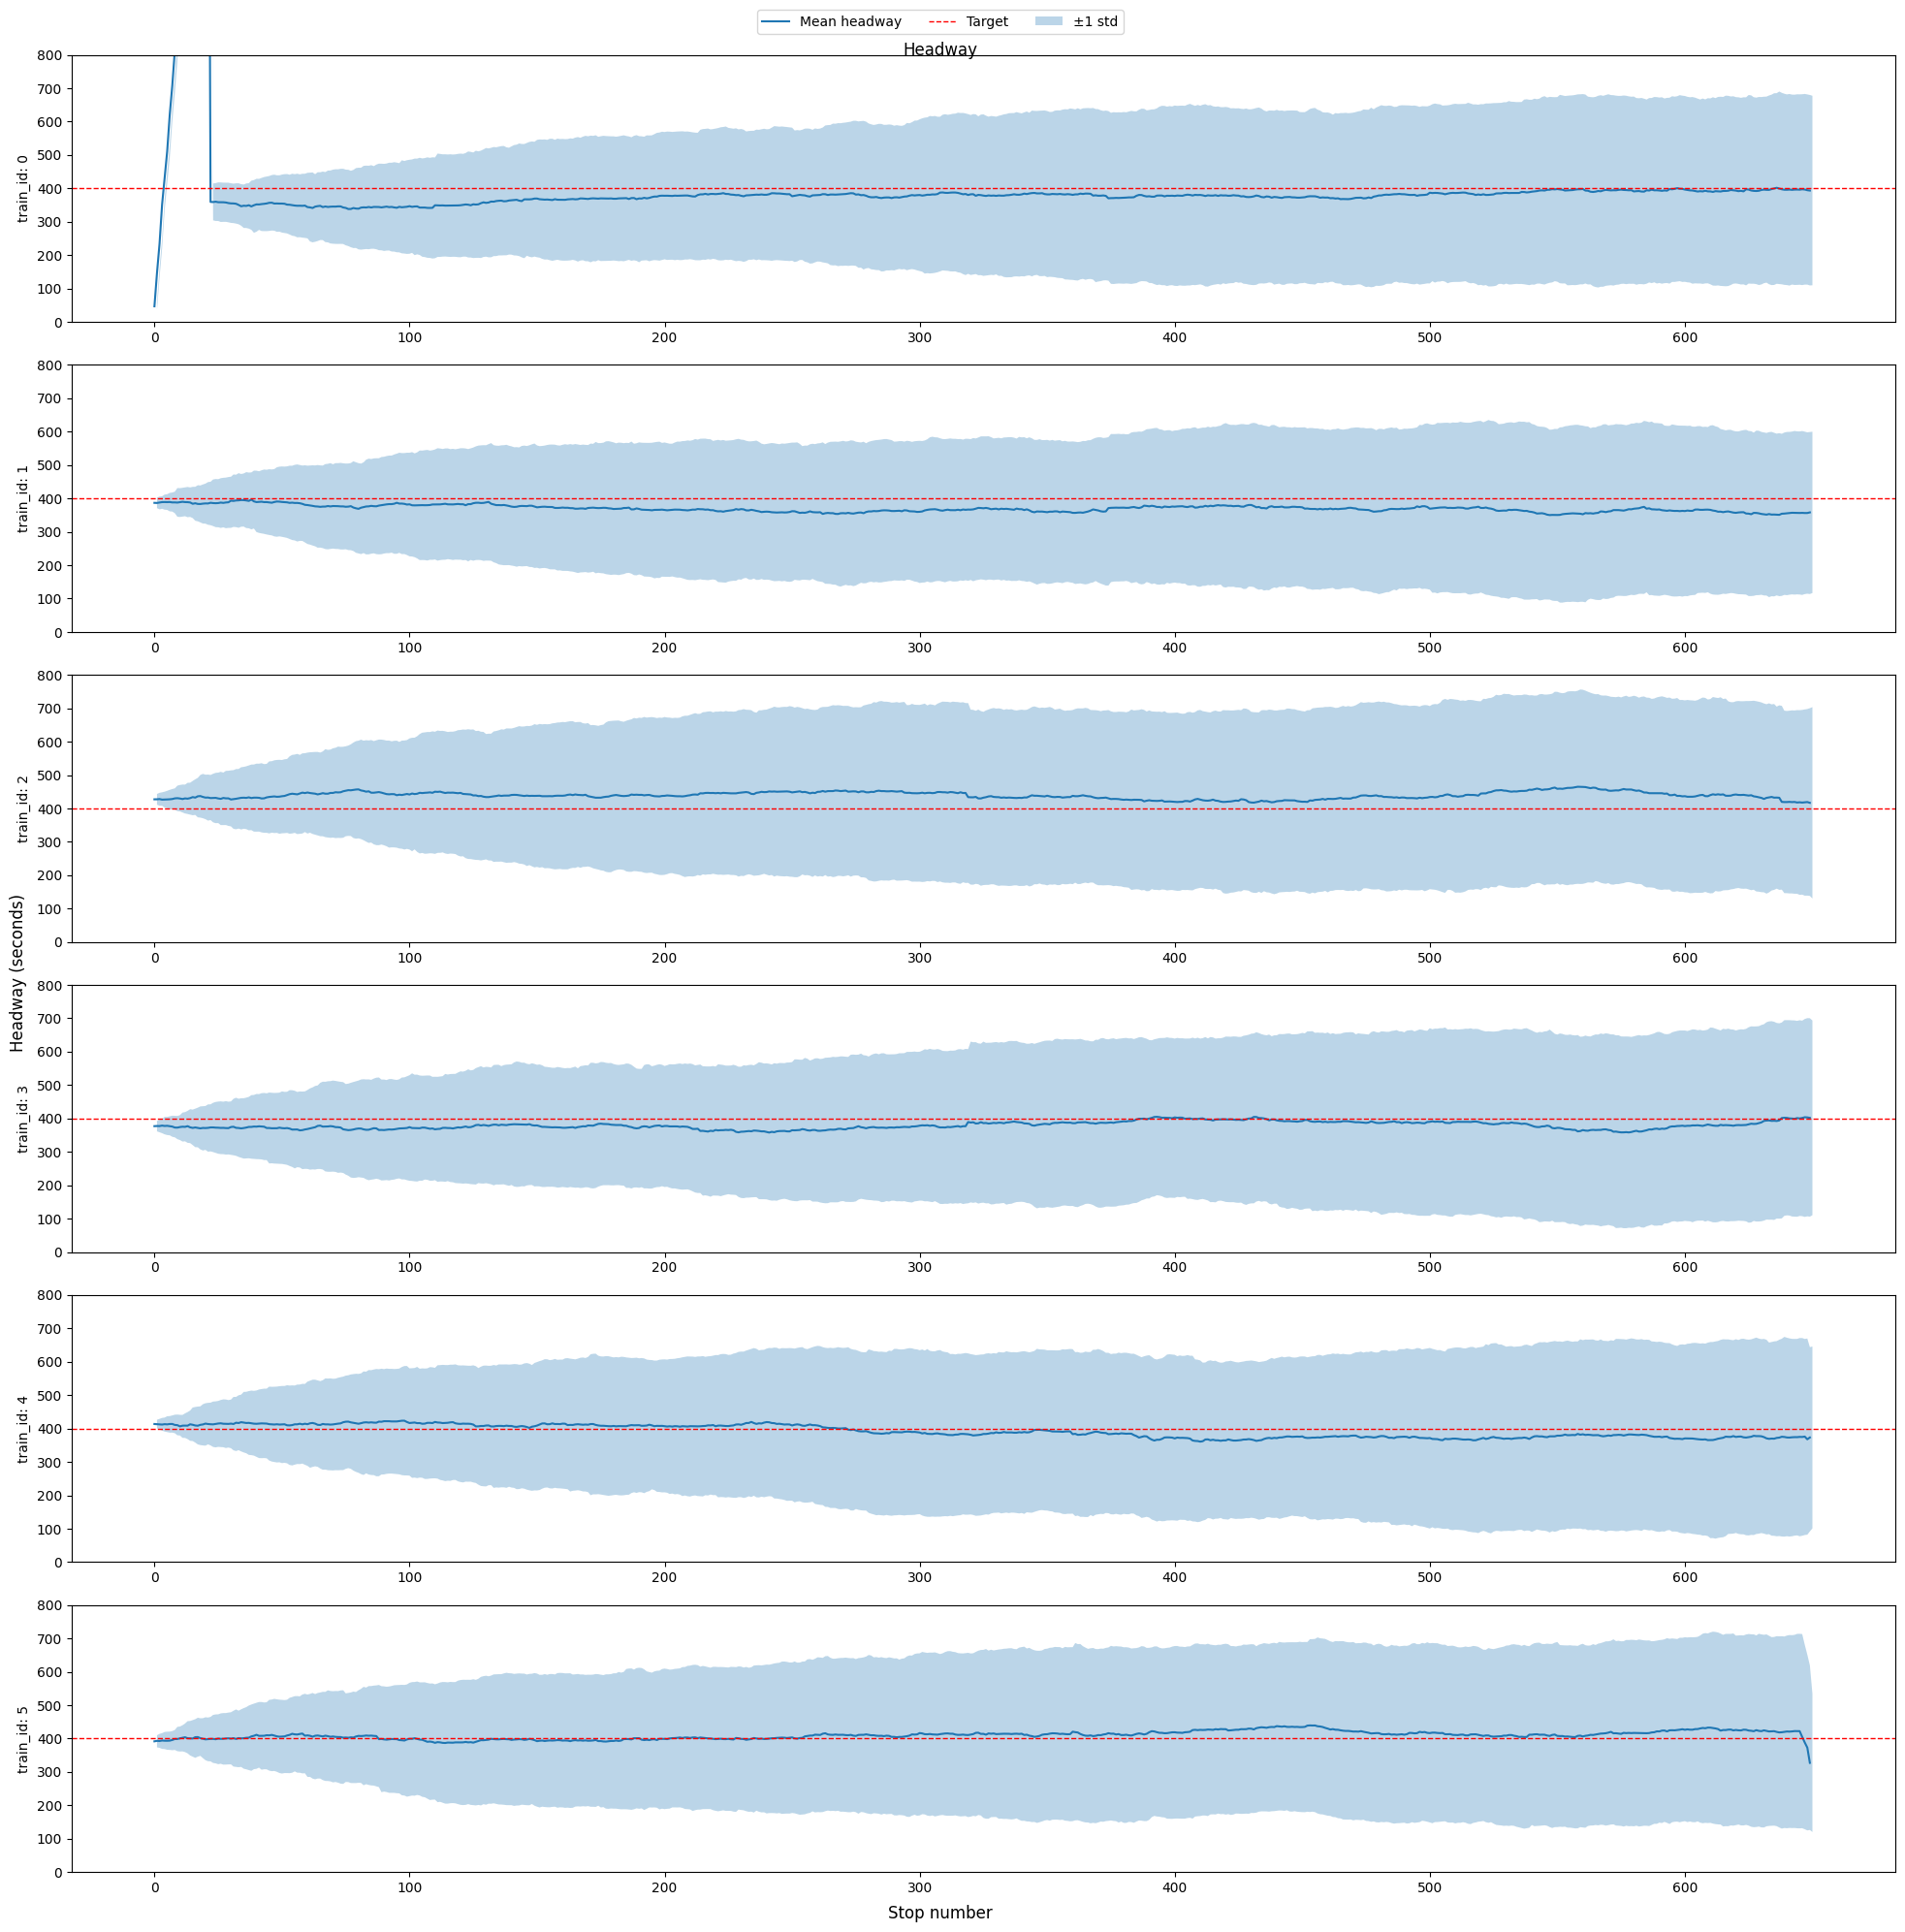

In [38]:
plot_headway(headway, 650)

## Relative Headway by Train and Stop

Computes `headway_rel` — each train's deviation from the target even-spacing headway
(`2400 / ntrains` seconds). Positive values mean the train is running with a larger-than-ideal
gap ahead; negative values mean it is closer than ideal (bunching risk/congestion).

Results are pivoted so each column is a `train_id`, rows are `stop` numbers (averaged across
replications), giving a matrix view of how headway deviation evolves through the line.

In [39]:
# Compute relative headway: deviation from ideal even-spacing target (2400s / ntrains)
headway['headway_rel'] = headway['headway'] - (2400/len(headway['train_id'].unique())) 

# Pivot so each column is a train_id, rows are (rep, stop) combinations
headway_pivot = headway.pivot_table(index=['rep', 'stop'], columns='train_id', values='headway_rel').reset_index()

# Drop rep column — only stop-level view needed
headway_pivot.drop(columns='rep', inplace=True)

# Remove rows with missing values (incomplete stop coverage across trains)
headway_pivot.dropna(inplace=True)

headway_pivot

train_id,stop,0,1,2,3,4,5
0,1,-345.0,-28.0,42.0,-33.0,20.0,-7.0
1,2,-249.0,-15.0,35.0,-7.0,4.0,-16.0
2,3,-158.0,-24.0,46.0,-12.0,-4.0,-2.0
3,4,-46.0,-22.0,40.0,-4.0,8.0,-16.0
4,5,31.0,-27.0,41.0,6.0,5.0,-20.0
...,...,...,...,...,...,...,...
66986,648,-21.0,383.0,-113.0,-28.0,-356.0,46.0
66987,649,-4.0,377.0,-126.0,-31.0,-355.0,36.0
66988,650,-7.0,386.0,-339.0,-1.0,-108.0,-37.0
66989,651,10.0,370.0,-317.0,-13.0,-110.0,-51.0


In [40]:
class PartialRegression:
    def __init__(self, headway, cycle=2400):
        self.headway = headway
        self.residual = pd.DataFrame()
        self.coef_ = pd.DataFrame()
        self.cycle = cycle          # total cycle time in seconds (default 40 min)
        self.run_partial_regression()

    def get_headway_pivot(self):
        # Compute relative headway: deviation from ideal even-spacing target (cycle / ntrains)
        self.headway['headway_rel'] = self.headway['headway'] - (self.cycle/len(self.headway['train_id'].unique())) 
        # Pivot so each column is a train_id, rows are (rep, stop) combinations
        self.headway_pivot = self.headway.pivot_table(index=['rep', 'stop'], columns='train_id', values='headway_rel').reset_index()
        # Remove rows with missing values (incomplete stop coverage across trains)
        self.headway_pivot.dropna(inplace=True)

    def get_iter(self):
        # Generate all (pred, target) pairs — every train paired against every other
        self.comb = []
        for pred in self.headway['train_id'].unique().tolist(): 
            confound = self.headway['train_id'].unique().tolist()
            confound.remove(pred)
            for target in confound:
                self.comb.append((pred, target))

    def plot(self, save_plot=False):
        l = len(self.headway['train_id'].unique().tolist())
        min_ = self.headway['train_id'].unique().min()
        max_ = self.headway['train_id'].unique().max()

        # Create l x l grid — one cell per (pred, target) pair
        fig, ax = plt.subplots(nrows=l, ncols=l, figsize=(20, 20))

        for pred, target in self.comb:
            # Filter residuals for this pair
            resd = self.residual[(self.residual['pred']==pred) & (self.residual['target']==target)]
            x = resd['pred_resd'].to_numpy()
            y = resd['target_resd'].to_numpy()
            
            # Retrieve fitted line coefficients for positive and negative correlation segments
            m1, c1 = self.coef_[(self.coef_['pred']==pred) & (self.coef_['target']==target)][['m_pos','c_pos']].values[0]
            m2, c2 = self.coef_[(self.coef_['pred']==pred) & (self.coef_['target']==target)][['m_neg','c_neg']].values[0]

            # Evaluate regression lines over fixed x range
            xaxis = np.linspace(-700, 700, 3)
            y1 = m1*xaxis + c1
            y2 = m2*xaxis + c2

            # Scatter residuals and overlay positive/negative regression lines
            ax[target, pred].scatter(x, y, alpha=0.1)
            ax[target, pred].plot(xaxis, y1, 'k--')
            ax[target, pred].plot(xaxis, y2, 'k--')

            # set x-y  limit
            ax[target, pred].set_xlim([-800, 1000])
            ax[target, pred].set_ylim([-800, 1000])

            # Remove ticks for cleaner grid appearance
            ax[target, pred].set_xticks([])
            ax[target, pred].set_yticks([])

            # add line equation as title
            ax[target, pred].set_title(f'{m1:.2f}x+{c1:.1f} | {m2:.2f}x+{c2:.1f}')

            # Label bottom row with target train id (x axis)
            if target == max_:
                ax[target, pred].set_xlabel(f'{pred}')

            # Label left column with pred train id (y axis)
            if pred == min_:
                ax[target, pred].set_ylabel(f'{target}')    

        for i in range(len(self.headway['train_id'].unique())):
            ax[i, i].set_xticks([])
            ax[i, i].set_yticks([])
            if i==min_:
                ax[i,i].set_ylabel(i)
            if i==max_:
                ax[i,i].set_xlabel(i)

        fig.supxlabel('Leading headway')
        fig.supylabel('Trailing headway')
        fig.suptitle('Partial Regression')
        if save_plot: fig.savefig('partial regression.svg', bbox_inches='tight', format='svg')
        fig.tight_layout()

    def run_partial_regression(self):
        self.get_headway_pivot()
        self.get_iter()

        for pred_id, target_id in self.comb:
            # All other trains act as confounds (controlled variables)
            confound = self.headway['train_id'].unique().tolist()
            confound.remove(pred_id)
            confound.remove(target_id)

            # Regress each of pred and target on confounds to isolate their unique variance
            target_model = LinearRegression().fit(self.headway_pivot[confound], self.headway_pivot[target_id])
            pred_model   = LinearRegression().fit(self.headway_pivot[confound], self.headway_pivot[pred_id])

            # Residuals = variation in pred/target not explained by confounds
            target_resd = self.headway_pivot[target_id] - target_model.predict(self.headway_pivot[confound])
            pred_resd   = self.headway_pivot[pred_id]   - pred_model.predict(self.headway_pivot[confound])

            # Store residuals alongside stop, pred, and target identifiers
            resd = pd.DataFrame({
                'rep':          self.headway_pivot['rep'],
                'stop':         self.headway_pivot['stop'],
                'pred':         pred_id,
                'target':       target_id,
                'pred_resd':    pred_resd.values,
                'target_resd':  target_resd.values})

            # Compute pointwise correlation between residuals (mean-centred)
            pred   = resd['pred_resd']   - resd['pred_resd'].mean()
            target = resd['target_resd'] - resd['target_resd'].mean()
            resd['cor'] = ((pred*target) / (np.sqrt((pred**2) * (target**2)))).round(2)

            self.residual = pd.concat([self.residual, resd], ignore_index=True)

            # Fit separate regression lines for positively and negatively correlated residuals
            m_lst = []
            c_lst = []
            for cor in [1, -1]:
                data = resd[resd['cor']==cor]
                x = data['pred_resd'].to_numpy().reshape(-1, 1)
                y = data['target_resd'].to_numpy()

                model = LinearRegression()
                model.fit(x, y)

                m_lst.append(round(model.coef_[0].item(), 3))
                c_lst.append(round(model.intercept_.item(), 3))

            # Store coefficients for positive (cor=1) and negative (cor=-1) segments
            self.coef_ = pd.concat([self.coef_,
                                    pd.DataFrame({
                                        'pred':   [pred_id],
                                        'target': [target_id],
                                        'm_pos':  [m_lst[0]],
                                        'c_pos':  [c_lst[0]],
                                        'm_neg':  [m_lst[1]],
                                        'c_neg':  [c_lst[1]],
                                    })], ignore_index=True)

In [41]:
pr = PartialRegression(headway)

In [42]:
pr.coef_

,pred,target,m_pos,c_pos,m_neg,c_neg
0,0,1,0.050,-19.095,-0.658,-7.302
1,0,2,0.043,-20.880,-0.614,-4.661
2,0,3,0.042,-17.920,-0.580,-3.788
3,0,4,0.049,-21.036,-0.664,-6.785
4,0,5,0.053,-23.057,-0.653,-3.519
5,1,0,3.659,145.255,-0.988,-12.300
6,1,2,0.659,-6.790,-0.893,-0.803
7,1,3,0.651,-10.546,-0.846,-1.327
8,1,4,0.770,-5.654,-0.897,1.272
9,1,5,0.953,-6.246,-0.932,1.367


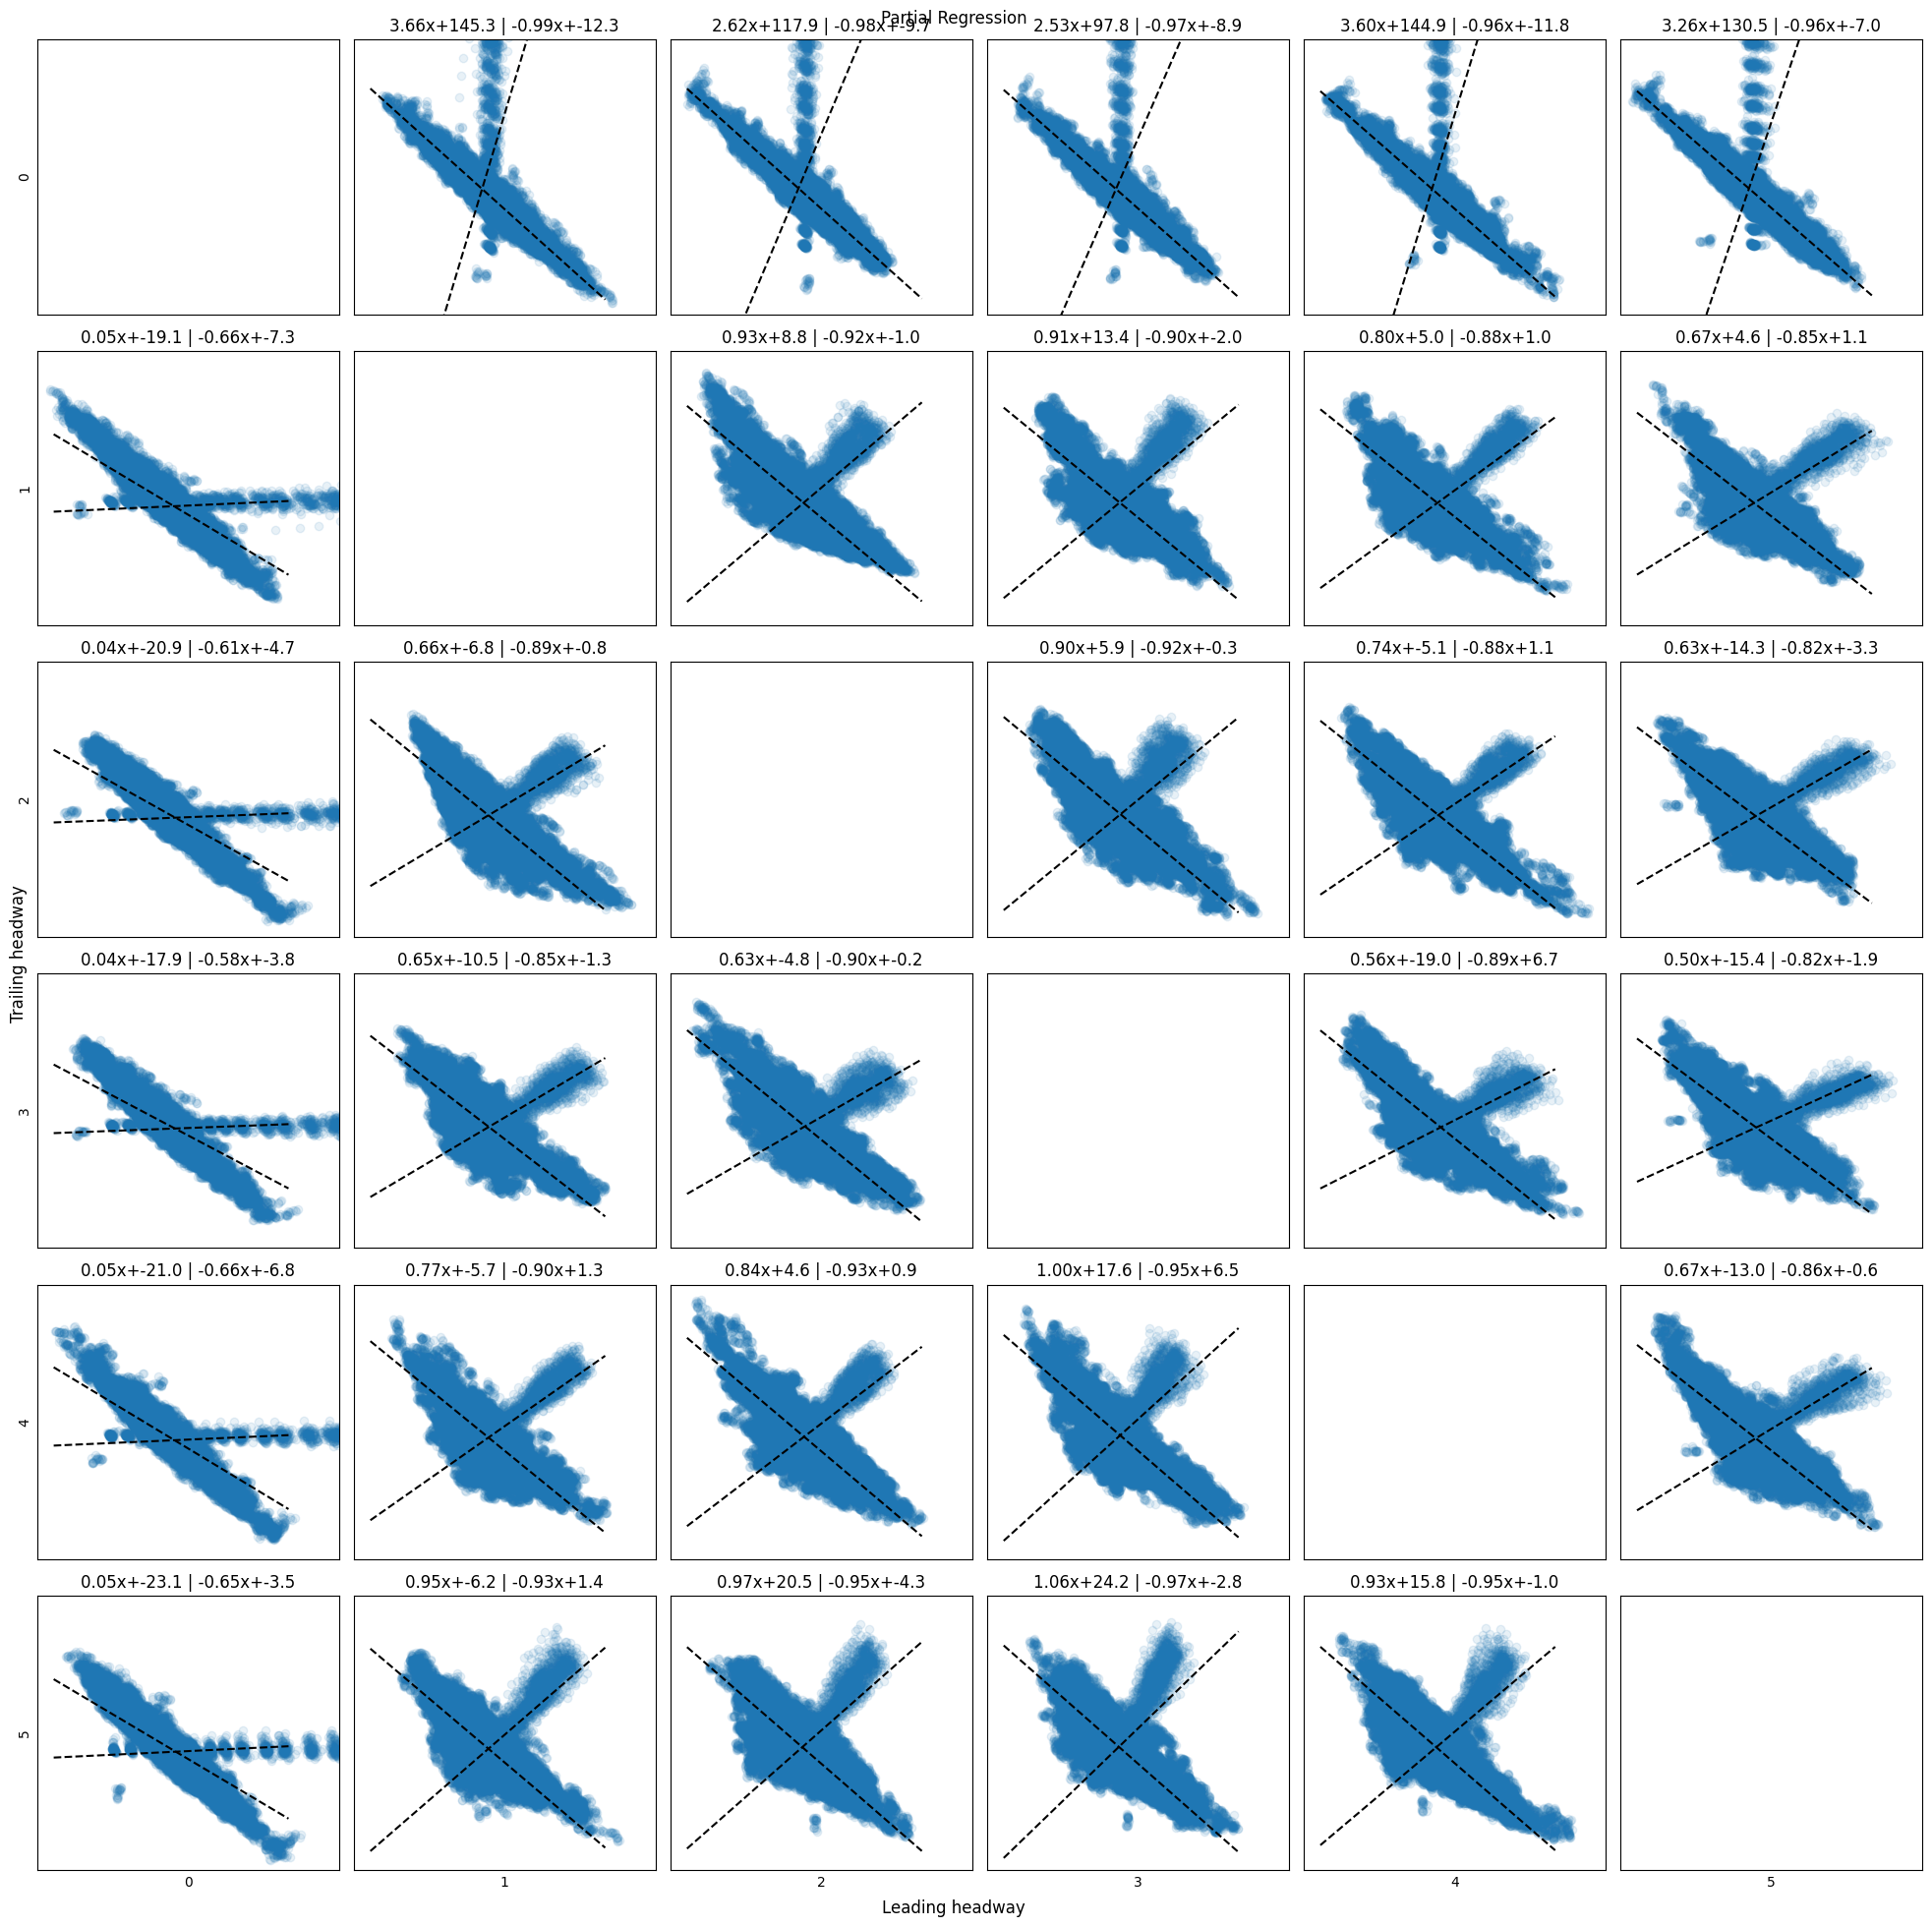

In [43]:
pr.plot()

In [44]:
resd = pr.residual
resd['unique_stop'] = ((resd['stop'] - 1) % 22) + 1
resd

,rep,stop,pred,target,pred_resd,target_resd,cor,unique_stop
0,1,1,0,1,-345.924544,4.037593,-1.0,1
1,1,2,0,1,-254.049265,15.504357,-1.0,2
2,1,3,0,1,-157.198014,12.305979,-1.0,3
3,1,4,0,1,-45.267913,14.255672,-1.0,4
4,1,5,0,1,33.020630,11.872754,1.0,5
...,...,...,...,...,...,...,...,...
1954765,100,648,5,4,137.159262,-286.178422,-1.0,10
1954766,100,649,5,4,124.963211,-292.174436,-1.0,11
1954767,100,650,5,4,-6.410003,-135.745762,1.0,12
1954768,100,651,5,4,-17.984501,-135.304238,1.0,13


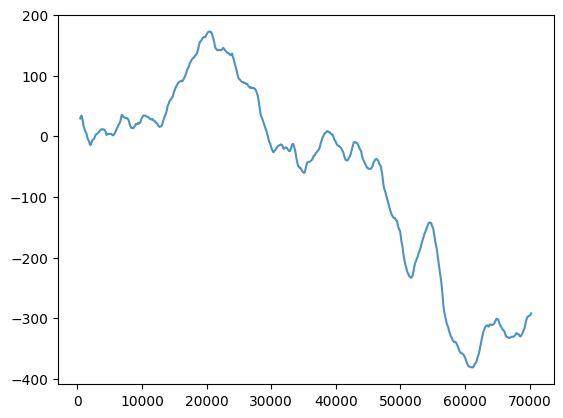

In [45]:
rep = 34
pred = 0
target = 1

temp = resd[(resd['pred']==pred)&(resd['target']==target)&(resd['rep']==rep)]
clock = timetable[(timetable['train_id']==target)&(timetable['rep']==rep)]

y = temp['target_resd'].ewm(span=20).mean() 
x = clock['departure'][:len(y)]

plt.plot(x, y, alpha=0.8)